### [ 주제 : 다른 기계로 일반화 검증 ]

지금까지는 전부 **id_00** 한 대였다. "id_00에서만 되는 거 아니냐"에 답하려면
**id_02 / id_04 / id_06**에서도 같은 방법이 통하는지 확인해야 한다.

- 통제 변인: **기계만** 바꾼다 (소음 -6dB 고정, 하이퍼파라미터 고정) → 순수하게 "기계 차이"만 봄
- `src`의 `machine` 파라미터로 기계 이름만 바꿔 재사용 (모듈화의 값어치)

In [1]:
## [0] 준비
import sys
sys.path.insert(0, '..')
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import torch
from src import config, data, train, evaluate

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('학습 장치 :', DEVICE)

학습 장치 : cuda


In [2]:
## [1] 기계별로 파이프라인 반복 (4대 × 1~2분 = 5~8분)
# TODO:
#  MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']
#  results = {}
#  for m in MACHINES:
#      torch.manual_seed(42)
#      trainNP, teN, teA = data.load_split_normalize(seed=42, machine=m)
#      model, _ = train.train_autoencoder(trainNP, DEVICE)
#      en = evaluate.recon_errors(model, teN, DEVICE)
#      ea = evaluate.recon_errors(model, teA, DEVICE)
#      results[m] = evaluate.compute_auc(en, ea)
#      print(f'{m}: AUC {results[m]:.4f}')
MACHINES = ['id_00', 'id_02', 'id_04', 'id_06']
results = {}
for m in MACHINES:
    torch.manual_seed(42)
    trainNP, teN, teA = data.load_split_normalize(seed=42, machine=m)
    model, _ = train.train_autoencoder(trainNP,DEVICE)
    en = evaluate.recon_errors(model, teN, DEVICE)
    ea = evaluate.recon_errors(model, teA, DEVICE)
    results[m] = evaluate.compute_auc(en, ea)
    print(f'{m} : AUC {results[m]:.4f}')

id_00 : AUC 0.9443
id_02 : AUC 0.7259
id_04 : AUC 0.5275
id_06 : AUC 0.4761


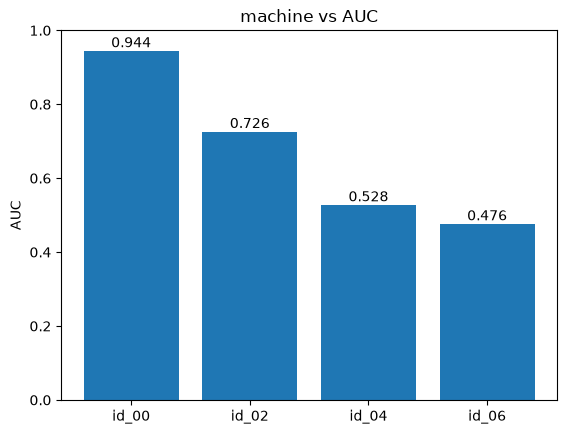

In [6]:
## [2] 기계별 AUC 막대그래프
# TODO:
#  import matplotlib.pyplot as plt
#  machines = list(results.keys())
#  aucs = [results[m] for m in machines]   # (또는 for문으로 담기)
#  plt.bar(machines, aucs); plt.ylim(0.5, 1.0); plt.ylabel('AUC'); plt.title('기계별 이상탐지 AUC')
#  for i in range(len(machines)): plt.text(i, aucs[i]+0.01, f'{aucs[i]:.3f}', ha='center')
#  plt.show()
import matplotlib.pyplot as plt
import koreanize_matplotlib
machines = list(results.keys())
aucs = [results[m] for m in machines]
plt.bar(machines,aucs)
plt.ylim(0, 1)
plt.ylabel('AUC')
plt.title('기계별 이상탐지 AUC')
for i in range(len(machines)):
    plt.text(i, aucs[i]+0.01, f'{aucs[i]:.3f}', ha='center')
plt.show()

## 결과 해석 (실행 후 채우기)

| 기계 | AUC |
|------|-----|
| id_00 | 0.9443 |
| id_02 | 0.7259 |
| id_04 | 0.5275 |
| id_06 | 0.4761 |

**관찰:**
- 4대 모두 높으면 → "id_00만이 아니라 여러 설비에 일반화된다"는 강한 근거
- 특정 기계만 낮으면 → 그 기계가 어려운 케이스 (왜인지 고민거리)